In [ ]:
!pip install timm
!pip install spikingjelly

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Cài đặt thư viện

In [ ]:
import os
import torch
import torch.nn as nn
import math
from sklearn.metrics import f1_score, confusion_matrix, classification_report
import torchvision
from torchvision.ops import MLP
import torchvision.transforms as transforms
import numpy as np

np.int = int
np.float = float
np.bool = bool

from spikingjelly.activation_based import neuron
from timm.models.layers import to_2tuple, trunc_normal_, DropPath
from timm.models.registry import register_model
from timm.models.vision_transformer import _cfg
import torch.nn.functional as F
from functools import partial
from spikingjelly.activation_based import layer, functional

from typing import Any, List, Mapping
from timm.models import register_model
from collections import Counter
from torch.utils.data import WeightedRandomSampler
from tqdm import tqdm

c:\Users\ROG\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\ROG\.venv\Lib\site-packages\timm\models\layers\__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
c:\Users\ROG\.venv\Lib\site-packages\timm\models\registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)


# Xây dựng model Spikformer

In [ ]:
__all__ = ['spikformer']


class MLP(nn.Module):
    def __init__(self, in_features, hidden_features=None, out_features=None, drop=0.):
        super().__init__()
        out_features = out_features or in_features
        hidden_features = hidden_features or in_features
        self.fc1_conv = nn.Conv2d(in_features, hidden_features, kernel_size=1, stride=1)
        self.fc1_bn = nn.BatchNorm2d(hidden_features)
        self.fc1_lif = neuron.LIFNode(tau=2.0, detach_reset=True,step_mode='m', backend='torch')

        self.fc2_conv = nn.Conv2d(hidden_features, out_features, kernel_size=1, stride=1)
        self.fc2_bn = nn.BatchNorm2d(out_features)
        self.fc2_lif = neuron.LIFNode(tau=2.0, detach_reset=True,step_mode='m', backend='torch')

        self.c_hidden = hidden_features
        self.c_output = out_features

    def forward(self, x):
        T,B,C,H,W = x.shape
        x = self.fc1_conv(x.flatten(0,1))
        x = self.fc1_bn(x).reshape(T,B,self.c_hidden,H,W).contiguous()
        x = self.fc1_lif(x)

        x = self.fc2_conv(x.flatten(0,1))
        x = self.fc2_bn(x).reshape(T,B,C,H,W).contiguous()
        x = self.fc2_lif(x)
        return x


class SSA(nn.Module):
    def __init__(self, dim, num_heads=8, qkv_bias=False, qk_scale=None, attn_drop=0., proj_drop=0., sr_ratio=1):
        super().__init__()
        assert dim % num_heads == 0, f"dim {dim} should be divided by num_heads {num_heads}."
        self.dim = dim
        self.num_heads = num_heads
        self.scale = 0.125
        self.q_conv = nn.Conv1d(dim, dim, kernel_size=1, stride=1,bias=False)
        self.q_bn = nn.BatchNorm1d(dim)
        self.q_lif = neuron.LIFNode(tau=2.0, detach_reset=True,step_mode='m', backend='torch')

        self.k_conv = nn.Conv1d(dim, dim, kernel_size=1, stride=1,bias=False)
        self.k_bn = nn.BatchNorm1d(dim)
        self.k_lif = neuron.LIFNode(tau=2.0, detach_reset=True,step_mode='m', backend='torch')

        self.v_conv = nn.Conv1d(dim, dim, kernel_size=1, stride=1,bias=False)
        self.v_bn = nn.BatchNorm1d(dim)
        self.v_lif = neuron.LIFNode(tau=2.0, detach_reset=True,step_mode='m', backend='torch')
        self.attn_lif = neuron.LIFNode(tau=2.0, v_threshold=0.5,detach_reset=True,step_mode='m', backend='torch')

        self.proj_conv = nn.Conv1d(dim, dim, kernel_size=1, stride=1)
        self.proj_bn = nn.BatchNorm1d(dim)
        self.proj_lif = neuron.LIFNode(tau=2.0, detach_reset=True,step_mode='m', backend='torch')

    def forward(self, x, res_attn):
        T,B,C,H,W = x.shape
        x = x.flatten(3)
        T, B, C, N = x.shape
        x_for_qkv = x.flatten(0, 1)
        q_conv_out = self.q_conv(x_for_qkv)
        q_conv_out = self.q_bn(q_conv_out).reshape(T,B,C,N).contiguous()
        q_conv_out = self.q_lif(q_conv_out)
        q = q_conv_out.transpose(-1, -2).reshape(T, B, N, self.num_heads, C//self.num_heads).permute(0, 1, 3, 2, 4).contiguous()

        k_conv_out = self.k_conv(x_for_qkv)
        k_conv_out = self.k_bn(k_conv_out).reshape(T,B,C,N).contiguous()
        k_conv_out = self.k_lif(k_conv_out)
        k = k_conv_out.transpose(-1, -2).reshape(T, B, N, self.num_heads, C//self.num_heads).permute(0, 1, 3, 2, 4).contiguous()

        v_conv_out = self.v_conv(x_for_qkv)
        v_conv_out = self.v_bn(v_conv_out).reshape(T,B,C,N).contiguous()
        v_conv_out = self.v_lif(v_conv_out)
        v = v_conv_out.transpose(-1, -2).reshape(T, B, N, self.num_heads, C//self.num_heads).permute(0, 1, 3, 2, 4).contiguous()

        x = k.transpose(-2,-1) @ v
        x = (q @ x) * self.scale

        x = x.transpose(3, 4).reshape(T, B, C, N).contiguous()
        x = self.attn_lif(x)
        x = x.flatten(0,1)
        x = self.proj_lif(self.proj_bn(self.proj_conv(x)).reshape(T,B,C,H,W))
        return x, v

class Block(nn.Module):
    def __init__(self, dim, num_heads, mlp_ratio=4., qkv_bias=False, qk_scale=None, drop=0., attn_drop=0.,
                 drop_path=0., norm_layer=nn.LayerNorm, sr_ratio=1):
        super().__init__()
        self.norm1 = norm_layer(dim)
        self.attn = SSA(dim, num_heads=num_heads, qkv_bias=qkv_bias, qk_scale=qk_scale,
                              attn_drop=attn_drop, proj_drop=drop, sr_ratio=sr_ratio)
        self.drop_path = DropPath(drop_path) if drop_path > 0. else nn.Identity()
        self.norm2 = norm_layer(dim)
        mlp_hidden_dim = int(dim * mlp_ratio)
        self.mlp = MLP(in_features=dim, hidden_features=mlp_hidden_dim, drop=drop)

    def forward(self, x, res_attn):
        x_attn, attn = (self.attn(x, res_attn))
        x = x + x_attn
        x = x + (self.mlp((x)))

        return x, attn


class SPS(nn.Module):
    def __init__(self, img_size_h=128, img_size_w=128, patch_size=4, in_channels=2, embed_dims=256):
        super().__init__()
        self.image_size = [img_size_h, img_size_w]
        patch_size = to_2tuple(patch_size)
        self.patch_size = patch_size
        self.C = in_channels
        self.H, self.W = self.image_size[0] // patch_size[0], self.image_size[1] // patch_size[1]
        self.num_patches = self.H * self.W
        self.proj_conv = nn.Conv2d(in_channels, embed_dims//8, kernel_size=3, stride=1, padding=1, bias=False)
        self.proj_bn = nn.BatchNorm2d(embed_dims//8)
        self.proj_lif = neuron.LIFNode(tau=2.0, detach_reset=True,step_mode='m', backend='torch')
        self.maxpool = torch.nn.MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)

        self.proj_conv1 = nn.Conv2d(embed_dims//8, embed_dims//4, kernel_size=3, stride=1, padding=1, bias=False)
        self.proj_bn1 = nn.BatchNorm2d(embed_dims//4)
        self.proj_lif1 = neuron.LIFNode(tau=2.0, detach_reset=True,step_mode='m', backend='torch')
        self.maxpool1 = torch.nn.MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)

        self.proj_conv2 = nn.Conv2d(embed_dims//4, embed_dims//2, kernel_size=3, stride=1, padding=1, bias=False)
        self.proj_bn2 = nn.BatchNorm2d(embed_dims//2)
        self.proj_lif2 = neuron.LIFNode(tau=2.0, detach_reset=True,step_mode='m', backend='torch')
        self.maxpool2 = torch.nn.MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)

        self.proj_conv3 = nn.Conv2d(embed_dims//2, embed_dims, kernel_size=3, stride=1, padding=1, bias=False)
        self.proj_bn3 = nn.BatchNorm2d(embed_dims)
        self.proj_lif3 = neuron.LIFNode(tau=2.0, detach_reset=True,step_mode='m', backend='torch')
        self.maxpool3 = torch.nn.MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)

        self.rpe_conv = nn.Conv2d(embed_dims, embed_dims, kernel_size=3, stride=1, padding=1, bias=False)
        self.rpe_bn = nn.BatchNorm2d(embed_dims)
        self.rpe_lif = neuron.LIFNode(tau=2.0, detach_reset=True,step_mode='m', backend='torch')

    def forward(self, x):
        T, B, C, H, W = x.shape
        x = self.proj_conv(x.flatten(0, 1)) # have some fire value
        x = self.proj_bn(x).reshape(T, B, -1, H, W).contiguous()
        x = self.proj_lif(x).flatten(0,1).contiguous()
        x = self.maxpool(x)

        x = self.proj_conv1(x)
        x = self.proj_bn1(x).reshape(T, B, -1, H//2, W//2).contiguous()
        x = self.proj_lif1(x).flatten(0, 1).contiguous()
        x = self.maxpool1(x)

        x = self.proj_conv2(x)
        x = self.proj_bn2(x).reshape(T, B, -1, H//4, W//4).contiguous()
        x = self.proj_lif2(x).flatten(0, 1).contiguous()
        x = self.maxpool2(x)

        x = self.proj_conv3(x)
        x = self.proj_bn3(x).reshape(T, B, -1, H//8, W//8).contiguous()
        x = self.proj_lif3(x).flatten(0, 1).contiguous()
        x = self.maxpool3(x)

        x_feat = x.reshape(T, B, -1, H//16, W//16).contiguous()
        x = self.rpe_conv(x)
        x = self.rpe_bn(x).reshape(T, B, -1, H//16, W//16).contiguous()
        x = self.rpe_lif(x)
        x = x + x_feat

        H, W = H // self.patch_size[0], W // self.patch_size[1]
        return x, (H, W)

class Spikformer(nn.Module):
    def __init__(self,
                 img_size_h=128, img_size_w=128, patch_size=16, in_channels=2, num_classes=11,
                 embed_dims=[64, 128, 256], num_heads=[1, 2, 4], mlp_ratios=[4, 4, 4], qkv_bias=False, qk_scale=None,
                 drop_rate=0., attn_drop_rate=0., drop_path_rate=0., norm_layer=nn.LayerNorm,
                 depths=[6, 8, 6], sr_ratios=[8, 4, 2]
                 ):
        super().__init__()
        self.num_classes = num_classes
        self.depths = depths

        dpr = [x.item() for x in torch.linspace(0, drop_path_rate, depths)]  # stochastic depth decay rule

        patch_embed = SPS(img_size_h=img_size_h,
                                 img_size_w=img_size_w,
                                 patch_size=patch_size,
                                 in_channels=in_channels,
                                 embed_dims=embed_dims)

        block = nn.ModuleList([Block(
            dim=embed_dims, num_heads=num_heads, mlp_ratio=mlp_ratios, qkv_bias=qkv_bias,
            qk_scale=qk_scale, drop=drop_rate, attn_drop=attn_drop_rate, drop_path=dpr[j],
            norm_layer=norm_layer, sr_ratio=sr_ratios)
            for j in range(depths)])

        setattr(self, f"patch_embed", patch_embed)
        setattr(self, f"block", block)

        # classification head
        self.head = nn.Linear(embed_dims, num_classes) if num_classes > 0 else nn.Identity()
        self.apply(self._init_weights)

    @torch.jit.ignore
    def _get_pos_embed(self, pos_embed, patch_embed, H, W):
        if H * W == self.patch_embed1.num_patches:
            return pos_embed
        else:
            return F.interpolate(
                pos_embed.reshape(1, patch_embed.H, patch_embed.W, -1).permute(0, 3, 1, 2),
                size=(H, W), mode="bilinear").reshape(1, -1, H * W).permute(0, 2, 1)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            trunc_normal_(m.weight, std=.02)
            if isinstance(m, nn.Linear) and m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.LayerNorm):
            nn.init.constant_(m.bias, 0)
            nn.init.constant_(m.weight, 1.0)

    def forward_features(self, x):

        block = getattr(self, f"block")
        patch_embed = getattr(self, f"patch_embed")

        x, (H, W) = patch_embed(x)
        attn = None
        for blk in block:
            x, attn = blk(x, attn)
        return x.flatten(3).mean(3)

    def forward(self, x):
        T = 4
        x = (x.unsqueeze(0)).repeat(T, 1, 1, 1, 1)
        x = self.forward_features(x)
        x = self.head(x.mean(0))
        return x


@register_model
def spikformer(pretrained=False,embed_dims=512, num_heads=8,depths=8,num_classes=1000, **kwargs):
    model = Spikformer(
        img_size_h=224, img_size_w=224,
        patch_size=16, embed_dims=embed_dims, num_heads=num_heads, mlp_ratios=4,
        in_channels=3, num_classes=num_classes, qkv_bias=False,
        norm_layer=partial(nn.LayerNorm, eps=1e-6), depths=depths, sr_ratios=1,
        **kwargs
    )
    model.default_cfg = _cfg()
    return model

# Triển khai model

_Biến đổi các tham số model để train trên thiết bị

In [8]:
device = 'cuda'
T = 4
backend = 'torch'

model = spikformer(
    embed_dims=256,
    num_heads=4,
    depths=4,
    num_classes=4).to(device)

In [9]:
num_params = sum(p.numel() for p in model.parameters())
print(f"{num_params/1e6:.2f} M")

4.15 M


In [33]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("CUDA:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))
for name, _ in model.named_parameters():
    print(name)

Device: cuda
CUDA: True
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU
patch_embed.proj_conv.weight
patch_embed.proj_bn.weight
patch_embed.proj_bn.bias
patch_embed.proj_conv1.weight
patch_embed.proj_bn1.weight
patch_embed.proj_bn1.bias
patch_embed.proj_conv2.weight
patch_embed.proj_bn2.weight
patch_embed.proj_bn2.bias
patch_embed.proj_conv3.weight
patch_embed.proj_bn3.weight
patch_embed.proj_bn3.bias
patch_embed.rpe_conv.weight
patch_embed.rpe_bn.weight
patch_embed.rpe_bn.bias
block.0.norm1.weight
block.0.norm1.bias
block.0.attn.q_conv.weight
block.0.attn.q_bn.weight
block.0.attn.q_bn.bias
block.0.attn.k_conv.weight
block.0.attn.k_bn.weight
block.0.attn.k_bn.bias
block.0.attn.v_conv.weight
block.0.attn.v_bn.weight
block.0.attn.v_bn.bias
block.0.attn.proj_conv.weight
block.0.attn.proj_conv.bias
block.0.attn.proj_bn.weight
block.0.attn.proj_bn.bias
block.0.norm2.weight
block.0.norm2.bias
block.0.mlp.fc1_conv.weight
block.0.mlp.fc1_conv.bias
block.0.mlp.fc1_bn.weight
block.0.mlp.fc1_bn.bias


In [ ]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=3,
)
criterion = nn.CrossEntropyLoss(
    label_smoothing=0.05
)

# Data Augmentation

In [4]:
def get_datasets():
    train_transform = transforms.Compose([
      transforms.Resize((224,224)),
      transforms.RandomHorizontalFlip(),
      transforms.RandomRotation(5),
      transforms.RandomAffine(
          degrees=0,
          translate=(0.05,0.05)
      ),
      transforms.ToTensor(),
      transforms.Normalize(
          [0.485,0.456,0.406],
          [0.229,0.224,0.225]
      )
  ])

    val_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])

    dest_path = ''

    trainset = torchvision.datasets.ImageFolder(
        root=os.path.join(dest_path, 'Training'),
        transform=train_transform
    )
    valset = torchvision.datasets.ImageFolder(
        root=os.path.join(dest_path, 'Testing'),
        transform=val_transform
    )
    testset = torchvision.datasets.ImageFolder(
        root=os.path.join(dest_path, 'Testing'),
        transform=val_transform
    )

    return trainset, valset, testset

# # Tổng hợp data và áp dụng Sample Weights

In [5]:
trainset, valset, testset = get_datasets()

print(f"\n✓ Train dataset: {len(trainset)} images, {len(trainset.classes)} classes")
print(f"✓ Validation dataset: {len(valset)} images, {len(valset.classes)} classes")
print(f"✓ Classes: {trainset.classes}")

labels = [label for _, label in trainset.samples]

class_counts = Counter(labels)

print("Class counts:", class_counts)

    # weight for each sample
sample_weights = []

for _, label in trainset.samples:

    sample_weights.append(
        1.0 / class_counts[label]
    )

sample_weights = torch.DoubleTensor(sample_weights)

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)


✓ Train dataset: 5600 images, 4 classes
✓ Validation dataset: 1600 images, 4 classes
✓ Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Class counts: Counter({0: 1400, 1: 1400, 2: 1400, 3: 1400})


# Train model

In [ ]:
best_acc = 0
patience = 6
counter = 0

for epoch in range(50):

    # =========================
    # TRAIN
    # =========================
    model.train()

    total_loss = 0
    train_correct = 0
    train_total = 0

    train_pbar = tqdm(trainloader, desc=f"Epoch {epoch+1}")

    for imgs, labels in train_pbar:

        imgs = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(imgs)

        if outputs.dim() == 3:
            outputs = outputs.mean(0)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()
        preds = outputs.argmax(1)

        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

        total_loss += loss.item()

        train_pbar.set_postfix(
            loss=f"{loss.item():.4f}",
            acc=f"{train_correct/train_total:.4f}"
        )

        functional.reset_net(model)

    train_loss = total_loss / len(trainloader)
    train_acc = train_correct / train_total

    # =========================
    # VALIDATION
    # =========================
    print("Starting validation...")

    model.eval()

    val_loss = 0
    correct = 0
    total = 0

    val_pbar = tqdm(valloader, desc="Validation")

    with torch.no_grad():

        for imgs, labels in val_pbar:

            imgs = imgs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(imgs)

            # Handle SNN temporal output
            if outputs.dim() == 3:
                outputs = outputs.mean(0)

            loss = criterion(outputs, labels)

            preds = outputs.argmax(1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            val_loss += loss.item()

            functional.reset_net(model)

    val_loss /= len(valloader)
    val_acc = correct / total

    print(
        f"Epoch {epoch+1} | "
        f"Train Loss {train_loss:.4f} | "
        f"Train Acc {train_acc:.4f} | "
        f"Val Loss {val_loss:.4f} | "
        f"Val Acc {val_acc:.4f}"
    )

    # =========================
    # LR Scheduler
    # =========================
    scheduler.step(val_loss)

    # =========================
    # EARLY STOPPING
    # =========================
    if val_acc > best_acc:

        best_acc = val_acc
        counter = 0

        torch.save(model.state_dict(), "best_model_Spikformer_brain_tumor_new.pth")

        print("Saved best model")

    else:

        counter += 1

        print(f"EarlyStopping counter: {counter}/{patience}")

        if counter >= patience:
            print("Early stopping triggered.")
            break

    # print learning rate
    for param_group in optimizer.param_groups:
        print("LR:", param_group['lr'])

Epoch 1: 100%|██████████| 350/350 [14:55<00:00,  2.56s/it, acc=0.7173, loss=0.3224]


Starting validation...


Validation: 100%|██████████| 100/100 [00:51<00:00,  1.93it/s]


Epoch 1 | Train Loss 0.8077 | Train Acc 0.7173 | Val Loss 0.8013 | Val Acc 0.7281
Saved best model
LR: 0.0001


Epoch 2: 100%|██████████| 350/350 [14:15<00:00,  2.44s/it, acc=0.8405, loss=0.5371]


...

Starting validation...


Validation: 100%|██████████| 100/100 [00:38<00:00,  2.58it/s]


Epoch 9 | Train Loss 0.3614 | Train Acc 0.9355 | Val Loss 0.5027 | Val Acc 0.8938
Saved best model
LR: 0.0001


Epoch 10:   3%|▎         | 12/350 [00:35<16:31,  2.93s/it, acc=0.9479, loss=0.3048]


KeyboardInterrupt: 

# Tiếp tục train model

In [ ]:
patience = 6
counter = 0

for epoch in range(50):

    # =========================
    # TRAIN
    # =========================
    model.train()

    total_loss = 0
    train_correct = 0
    train_total = 0

    train_pbar = tqdm(trainloader, desc=f"Epoch {epoch+10}")

    for imgs, labels in train_pbar:

        imgs = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(imgs)

        if outputs.dim() == 3:
            outputs = outputs.mean(0)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        preds = outputs.argmax(1)

        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

        total_loss += loss.item()

        train_pbar.set_postfix(
            loss=f"{loss.item():.4f}",
            acc=f"{train_correct/train_total:.4f}"
        )

        functional.reset_net(model)

    train_loss = total_loss / len(trainloader)
    train_acc = train_correct / train_total

    # =========================
    # VALIDATION
    # =========================
    print("Starting validation...")

    model.eval()

    val_loss = 0
    correct = 0
    total = 0

    val_pbar = tqdm(valloader, desc="Validation")

    with torch.no_grad():

        for imgs, labels in val_pbar:

            imgs = imgs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(imgs)

            # Handle SNN temporal output
            if outputs.dim() == 3:
                outputs = outputs.mean(0)

            loss = criterion(outputs, labels)

            preds = outputs.argmax(1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            val_loss += loss.item()

            functional.reset_net(model)

    val_loss /= len(valloader)
    val_acc = correct / total

    print(
        f"Epoch {epoch+10} | "
        f"Train Loss {train_loss:.4f} | "
        f"Train Acc {train_acc:.4f} | "
        f"Val Loss {val_loss:.4f} | "
        f"Val Acc {val_acc:.4f}"
    )

    # =========================
    # LR Scheduler
    # =========================
    scheduler.step(val_loss)

    # =========================
    # EARLY STOPPING
    # =========================
    if val_acc > best_acc:

        best_acc = val_acc
        counter = 0

        torch.save(model.state_dict(), "best_model_Spikformer_brain_tumor_new.pth")

        print("Saved best model")

    else:

        counter += 1

        print(f"EarlyStopping counter: {counter}/{patience}")

        if counter >= patience:
            print("Early stopping triggered.")
            break

    # print learning rate
    for param_group in optimizer.param_groups:
        print("LR:", param_group['lr'])

Epoch 10: 100%|██████████| 350/350 [13:07<00:00,  2.25s/it, acc=0.9427, loss=0.2555]


Starting validation...


Validation: 100%|██████████| 100/100 [00:39<00:00,  2.53it/s]


Epoch 10 | Train Loss 0.3561 | Train Acc 0.9427 | Val Loss 0.4817 | Val Acc 0.9081
Saved best model
LR: 0.0001


Epoch 11: 100%|██████████| 350/350 [12:52<00:00,  2.21s/it, acc=0.9430, loss=0.2534]


...

Epoch 13: 100%|██████████| 350/350 [12:26<00:00,  2.13s/it, acc=0.9514, loss=0.3710]


Starting validation...


Validation: 100%|██████████| 100/100 [00:24<00:00,  4.08it/s]


Epoch 13 | Train Loss 0.3279 | Train Acc 0.9514 | Val Loss 0.4832 | Val Acc 0.9131
Saved best model
LR: 0.0001


Epoch 14:  33%|███▎      | 114/350 [04:12<08:42,  2.22s/it, acc=0.9578, loss=0.5113]

In [ ]:
patience = 6
counter = 0
model.load_state_dict(
        torch.load(
            "best_model_Spikformer_brain_tumor_new.pth",
            map_location=device
        )
    )
best_acc = 0.9131
for epoch in range(50):

    # =========================
    # TRAIN
    # =========================
    model.train()

    total_loss = 0
    train_correct = 0
    train_total = 0

    train_pbar = tqdm(trainloader, desc=f"Epoch {epoch+14}")

    for imgs, labels in train_pbar:

        imgs = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(imgs)

        if outputs.dim() == 3:
            outputs = outputs.mean(0)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        preds = outputs.argmax(1)

        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

        total_loss += loss.item()

        train_pbar.set_postfix(
            loss=f"{loss.item():.4f}",
            acc=f"{train_correct/train_total:.4f}"
        )

        functional.reset_net(model)

    train_loss = total_loss / len(trainloader)
    train_acc = train_correct / train_total

    # =========================
    # VALIDATION
    # =========================
    print("Starting validation...")

    model.eval()

    val_loss = 0
    correct = 0
    total = 0

    val_pbar = tqdm(valloader, desc="Validation")

    with torch.no_grad():

        for imgs, labels in val_pbar:

            imgs = imgs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(imgs)

            # Handle SNN temporal output
            if outputs.dim() == 3:
                outputs = outputs.mean(0)

            loss = criterion(outputs, labels)

            preds = outputs.argmax(1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            val_loss += loss.item()

            functional.reset_net(model)

    val_loss /= len(valloader)
    val_acc = correct / total

    print(
        f"Epoch {epoch+14} | "
        f"Train Loss {train_loss:.4f} | "
        f"Train Acc {train_acc:.4f} | "
        f"Val Loss {val_loss:.4f} | "
        f"Val Acc {val_acc:.4f}"
    )

    # =========================
    # LR Scheduler
    # =========================
    scheduler.step(val_loss)

    # =========================
    # EARLY STOPPING
    # =========================
    if val_acc > best_acc:

        best_acc = val_acc
        counter = 0

        torch.save(model.state_dict(), "best_model_Spikformer_brain_tumor_new.pth")

        print("Saved best model")

    else:

        counter += 1

        print(f"EarlyStopping counter: {counter}/{patience}")

        if counter >= patience:
            print("Early stopping triggered.")
            break

    # print learning rate
    for param_group in optimizer.param_groups:
        print("LR:", param_group['lr'])

Epoch 14: 100%|██████████| 350/350 [11:10<00:00,  1.91s/it, acc=0.9513, loss=0.1553]


Starting validation...


Validation: 100%|██████████| 100/100 [00:50<00:00,  1.97it/s]


Epoch 14 | Train Loss 0.1549 | Train Acc 0.9513 | Val Loss 0.3646 | Val Acc 0.9031
EarlyStopping counter: 1/6
LR: 0.0001


Epoch 15: 100%|██████████| 350/350 [12:36<00:00,  2.16s/it, acc=0.9539, loss=0.1196]


...

Starting validation...


Validation: 100%|██████████| 100/100 [00:37<00:00,  2.64it/s]


Epoch 28 | Train Loss 0.0385 | Train Acc 0.9882 | Val Loss 0.3590 | Val Acc 0.9406
Saved best model
LR: 2.5e-05


Epoch 29:   2%|▏         | 8/350 [00:19<13:50,  2.43s/it, acc=0.9766, loss=0.0239]


KeyboardInterrupt: 

# Đánh giá metric của model


Running evaluation...


100%|██████████| 100/100 [00:30<00:00,  3.32it/s, acc=0.941]



===== RESULTS =====
Accuracy       : 0.9406
Loss           : 0.3590
F1 (macro)     : 0.9391
F1 (weighted)  : 0.9391

Classification Report:
              precision    recall  f1-score   support

      glioma       0.99      0.80      0.88       400
  meningioma       0.90      0.96      0.93       400
     notumor       0.90      1.00      0.95       400
   pituitary       0.99      1.00      0.99       400

    accuracy                           0.94      1600
   macro avg       0.94      0.94      0.94      1600
weighted avg       0.94      0.94      0.94      1600



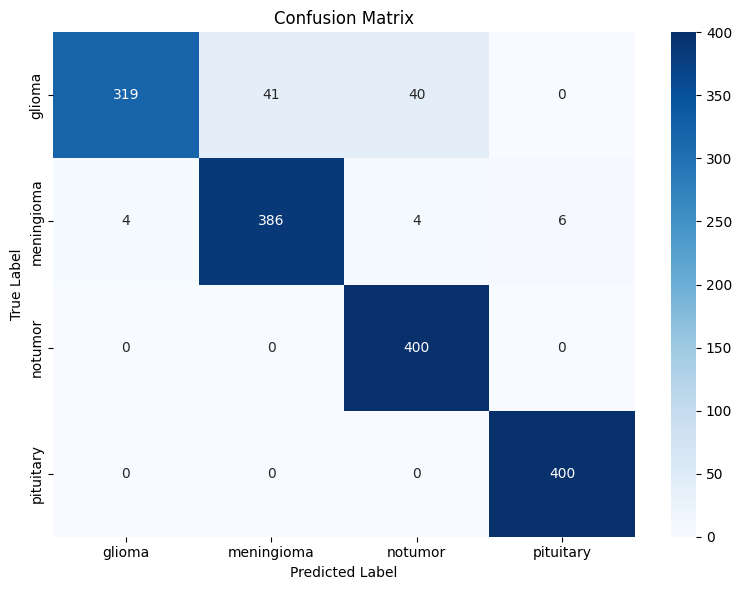

In [ ]:
model.load_state_dict(
    torch.load(
        "best_model_Spikformer_brain_tumor_new.pth",
        map_location=device
    )
)
testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=16,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=2,
    drop_last=True
)

model.eval()
criterion = nn.CrossEntropyLoss()

correct, total = 0, 0
total_loss = 0

all_preds = []
all_labels = []

print("\nRunning evaluation...")
with torch.no_grad():
    pbar = tqdm(testloader)
    for imgs, labels in pbar:
        imgs = imgs.to(device)
        labels = labels.to(device)

        outputs = model(imgs)

        if outputs.dim() == 3:
            outputs = outputs.mean(0)

        loss = criterion(outputs, labels)

        preds = outputs.argmax(1)

        total_loss += loss.item()

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        functional.reset_net(model)

        pbar.set_postfix(acc=correct / total)

acc = correct / total
avg_loss = total_loss / len(testloader)

f1_macro = f1_score(all_labels, all_preds, average='macro')
f1_weighted = f1_score(all_labels, all_preds, average='weighted')
cm = confusion_matrix(all_labels, all_preds)

print("\n===== RESULTS =====")
print(f"Accuracy       : {acc:.4f}")
print(f"Loss           : {avg_loss:.4f}")
print(f"F1 (macro)     : {f1_macro:.4f}")
print(f"F1 (weighted)  : {f1_weighted:.4f}")

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=testset.classes))
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=testset.classes,
    yticklabels=testset.classes
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()